1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from matplotlib.ticker import MultipleLocator
import scipy
from scipy.stats import norm

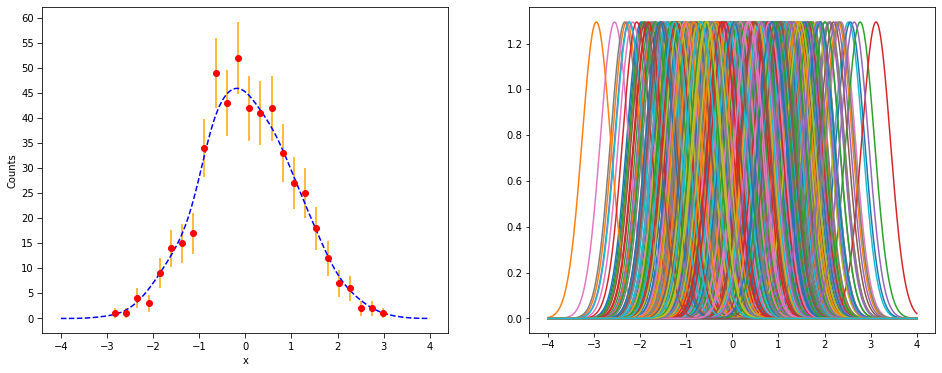

In [19]:
mean = 0
std = 1
count = 500
nbins = 25

fig, (ax, ax_b) = plt.subplots(nrows=1, ncols=2, figsize=(16,6))

x = np.random.normal(mean, std, count)
bin_count, bins = np.histogram(x, nbins)
bin_center = (bins[1:] + bins[:-1]) / 2 
#ax.hist(x, bins=25, histtype = 'step')
#ax.hist(bins[:-1], bins, weights=bin_count)
bin_error = []
for b in bin_count:
    bin_error.append(sqrt(b))

ax.errorbar(bin_center, bin_count, bin_error, fmt='or', ecolor='orange')
ax.set_xlabel("x")
ax.set_ylabel("Counts")
ax.tick_params(which="major", length=5)
ax.yaxis.set_major_locator(MultipleLocator(5))

l = np.linspace(-4, 4, 500)
total_gauss = np.zeros_like(l)
for element in x:
    x_std = 1.06 * x.std() * x.size**(-1/5)
    gauss = norm.pdf(l, loc=element, scale=x_std)
    ax_b.plot(l, gauss)
    total_gauss += gauss

total_gauss *= scipy.integrate.trapezoid(bin_count, bin_center) / scipy.integrate.trapezoid(total_gauss, l)

ax.plot(l, total_gauss, linestyle='--', c='b')
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

--2025-12-04 09:20:38--  https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35 [following]
--2025-12-04 09:20:38--  https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucfd4a44eeaa10bc726a1c5d8101.dl.dropboxusercontent.com/cd/0/inline/C2aWXbVltboHhXI06vXdYiov_EdKa6vPrQm4W0mZp9exQ5clwMhW3BrEBKOz8EJrgCvt0ZFyz1eiAsA4nmf2TGD-uvnpxriNMgYx3vPgrmJykPZXcGSVHkHgqsaei4VFu8U/file# [following]
--2025-12-04 09:20:39--  https://ucfd4a44eeaa10bc726a1c5d8101.

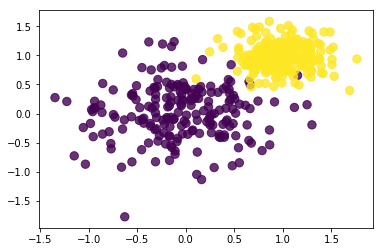

In [35]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

[[3.0937506  0.04115626]
 [0.04115626 2.74691365]]
[[1.84917736 0.13952355]
 [0.13952355 1.9501456 ]]


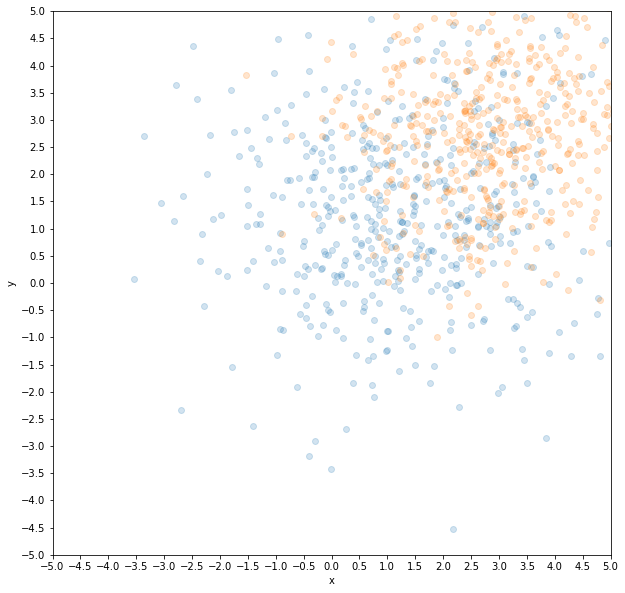

In [58]:
category = 2
rand_mean = np.random.uniform(-3, 3, category)
rand_std = np.random.uniform(0, 2, category)
n_point = np.random.normal(500, 50, category).astype(int)

fig, ax = plt.subplots(figsize=(10,10))

for rm, rs, n in zip(rand_mean, rand_std, n_point):
    x = np.random.normal(rm, rs, n)
    y = np.random.normal(rm, rs, n)
    ax.scatter(x,y, alpha=0.2)
    print(np.cov(x,y))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
plt.show()


3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot